In [2]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
#from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm
import xesmf as xe

In [2]:
z500=xr.open_dataset('data/era5_zg.nc')

In [ ]:
zg = z500.rename({'valid_time': 'time', 'latitude':'lat', 'longitude':'lon'})
# Ensure proper ordering
zg = zg.sortby(['lat', 'lon'])
#display(zg_x.lon[0])

# Target grid 1.0x1.0 resolution
ds_out = xe.util.grid_global(1.0, 1.0)

# Regrid
regridder = xe.Regridder(
    zg, ds_out,
    'bilinear',
    periodic=True,
    ignore_degenerate=True
)

ds_1deg = regridder(zg, keep_attrs=True)

# Extract 1D coords
lon_1d = ds_1deg.lon[0, :].values
lat_1d = ds_1deg.lat[:, 0].values

# Assign AND enforce them as dimension coords
ds_1deg = ds_1deg.rename({"x": "lon", "y": "lat"})

ds_1deg = ds_1deg.assign_coords({
    "lon": ("lon", lon_1d),
    "lat": ("lat", lat_1d)
})

display(ds_1deg)
zg_x = ds_1deg.sel(pressure_level=500).z.drop_vars('pressure_level').sel(time=slice('1950','2025'),lat=slice(-90,0))



In [ ]:
zg_x

<xarray.DataArray 'z' (time: 901, lat: 90, lon: 360)> Size: 117MB
array([[[50609.793, 50609.793, 50609.543, ..., 50610.293, 50610.043,
         50609.793],
        [50562.043, 50561.293, 50560.543, ..., 50564.543, 50563.543,
         50562.793],
        [50506.293, 50505.293, 50504.543, ..., 50510.043, 50508.793,
         50507.543],
        ...,
        [57176.543, 57175.043, 57172.543, ..., 57180.043, 57179.293,
         57178.043],
        [57174.543, 57173.293, 57171.543, ..., 57177.293, 57177.043,
         57176.293],
        [57173.043, 57172.043, 57170.293, ..., 57175.543, 57175.043,
         57174.293]],

       [[49336.117, 49336.617, 49337.117, ..., 49334.617, 49335.117,
         49335.617],
        [49381.117, 49382.117, 49383.117, ..., 49378.367, 49379.367,
         49380.367],
        [49393.617, 49395.367, 49397.117, ..., 49388.867, 49390.367,
         49391.867],
...
        [57569.664, 57570.914, 57571.164, ..., 57568.914, 57568.914,
         57569.164],
        [57566.664, 57567.164, 57567.664, ..., 57564.914, 57565.164,
         57566.164],
        [57563.664, 57563.914, 57563.664, ..., 57563.914, 57563.664,
         57563.664]],

       [[50183.613, 50183.113, 50182.613, ..., 50185.613, 50184.863,
         50184.363],
        [50114.863, 50112.613, 50110.613, ..., 50121.613, 50119.363,
         50117.113],
        [50034.863, 50032.113, 50029.363, ..., 50044.613, 50041.363,
         50037.863],
        ...,
        [57496.613, 57497.613, 57498.113, ..., 57496.363, 57496.863,
         57496.363],
        [57492.613, 57493.613, 57494.613, ..., 57492.363, 57492.613,
         57492.613],
        [57490.113, 57490.363, 57490.863, ..., 57489.363, 57489.863,
         57490.113]]], shape=(901, 90, 360), dtype=float32)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-01-01
    expver   (time) <U4 14kB ...
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      519840
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

In [ ]:
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def var_prepper(da, months_list, wghts_bool=True):
    da_sel=extract_seasonal_data(da, months_list)
    ##1 Anomalies
    da_an=compute_anomaly(da_sel)
    print('Anomalies computed')
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    print('Data is detrended')
    ##cut the weight by latitude part
    da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season= da_wght #extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    #da_masked=sea_mask(da_season_mean) #not necessary for 500hPa?
    da_masked=da_season_mean.to_dataset(name='Z500')
    return da_masked

In [ ]:
z500_SON=var_prepper(zg_x, [9,10,11])

Anomalies computed
Data is detrended


In [ ]:
z500_DJF=var_prepper(zg_x,[12,1,2])

Anomalies computed
Data is detrended


In [ ]:
years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

z500_SON=exclude_years_xr(z500_SON, years_to_drop)

cut_years=[1950,2003,2020,2025]
z500_DJF=exclude_years_xr(z500_DJF, cut_years)

In [ ]:
display(z500_DJF)

path='ERA5_dyn_data_ready/'
z500_SON.to_netcdf(path=path+'z500_SON.nc', format='NETCDF4')
z500_DJF.to_netcdf(path=path+'z500_DJF.nc', format='NETCDF4')

<xarray.Dataset> Size: 19MB
Dimensions:  (lon: 360, lat: 90, year: 72)
Coordinates:
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5
  * year     (year) int64 576B 1951 1952 1953 1954 1955 ... 2021 2022 2023 2024
Data variables:
    Z500     (year, lat, lon) float64 19MB -1.871 -1.871 -1.871 ... 0.8347 0.836

RUN FROM HERE

In [3]:
z500_SON=xr.open_dataset('ERA5_dyn_data_ready/z500_SON.nc')
z500_DJF=xr.open_dataset('ERA5_dyn_data_ready/z500_DJF.nc')

Import driver data

In [7]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('data_ready/5.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('data_ready/4.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 6kB
Dimensions:        (year: 72)
Coordinates:
  * year           (year) int64 576B 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t_Andes        (year) float64 576B -1.791 0.5614 -0.2617 ... 0.7645 0.6017
    precip_Andes   (year) float64 576B 0.129 0.4549 -1.375 ... -0.2223 -1.51
    ENSO           (year) float64 576B -0.6866 0.5838 0.3068 ... -0.7546 1.632
    IOD            (year) float64 576B 0.2555 0.6281 1.26 ... 0.9651 4.209
    EDJ            (year) float64 576B 1.783 0.6677 -0.5056 ... 0.9377 0.1875
    EDJ_lat        (year) float64 576B -0.6985 1.359 -0.9556 ... -2.241 -2.241
    EDJ_lat_nostd  (year) float64 576B -52.07 -48.64 -52.5 ... -54.64 -54.64
    SPV            (year) float64 576B 0.2633 -0.6312 1.451 ... 2.242 1.702 1.85
    A_SAM          (year) float64 576B 0.233 -1.135 -2.197 ... 1.774 0.05365
    S_SAM          (year) float64 576B 0.6038 -1.058 0.1437 ... 1.631 1.93 1.88

In [8]:
##SON data
ds_SON = xr.merge([z500_SON, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([z500_DJF, era_DJF_LaPlata_array])

In [9]:
display(ds_SON)

<xarray.Dataset> Size: 19MB
Dimensions:         (lon: 360, lat: 90, year: 72)
Coordinates:
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat             (lat) float64 720B -89.5 -88.5 -87.5 ... -2.5 -1.5 -0.5
  * year            (year) int64 576B 1951 1952 1953 1954 ... 2022 2023 2024
Data variables:
    Z500            (year, lat, lon) float64 19MB ...
    t_LaPlata       (year) float64 576B 1.008 -0.3405 0.001028 ... 1.707 1.963
    precip_LaPlata  (year) float64 576B 1.251 -1.636 2.576 ... 1.411 -0.9275
    ENSO            (year) float64 576B 0.8577 -0.08958 0.6573 ... 1.719 -0.33
    IOD             (year) float64 576B 0.1126 -0.4963 0.1753 ... 3.25 0.8168
    EDJ             (year) float64 576B -0.4128 -0.3213 ... -0.2175 -0.763
    EDJ_lat         (year) float64 576B 1.568 -1.369 0.8338 ... -0.1452 1.446
    EDJ_lat_nostd   (year) float64 576B -48.64 -53.79 -49.93 ... -51.64 -48.86
    SPV             (year) float64 576B -1.639 0.7289 -1.065 ... 0.9296 -0.05547
    A_SAM           (year) float64 576B -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM           (year) float64 576B -2.402 -0.386 -1.018 ... 0.5597 0.9627

Regressions and Maps

In [10]:


def lin_model_fast(y, x_main, *x_controls):
    """
    y         : (window,)
    x_main    : (window,)
    x_controls: (window,)

    Returns
    -------
    coef_main : float
    """

    # stack predictors
    X_list = [x_main] + list(x_controls)
    X = np.stack(X_list, axis=1)  # shape (window, n_predictors)

    # remove NaNs
    mask = ~np.any(np.isnan(X), axis=1) & ~np.isnan(y)
    if mask.sum() < X.shape[1]:  # not enough data
        return np.nan

    X = X[mask]
    y = y[mask]

    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        return beta[0]  # coefficient of main predictor
    except np.linalg.LinAlgError:
        return np.nan
import xarray as xr

def sensitivity_analysis_fast(ds_rolled, target, driver, controls=None):
    """
    Perform regression for each grid point and rolling window.

    Parameters
    ----------
    ds_rolled : Dataset (year, window, lat, lon)
    target    : str (e.g. 't2m')
    driver    : str (main predictor, e.g. 'ENSO')
    controls  : list of str (optional)

    Returns
    -------
    coef_da : DataArray (year, lat, lon)
    """

    y = ds_rolled[target]
    x_main = ds_rolled[driver]

    if controls is not None:
        x_controls = [ds_rolled[var] for var in controls]
    else:
        x_controls = []

    coef = xr.apply_ufunc(
        lin_model_fast,
        y,
        x_main,
        *x_controls,
        input_core_dims=[["window"]] * (2 + len(x_controls)),
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    return coef


def conditioning_everything_fast(ds, driver_list, target, total_eff=False):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif 'SPV' in driver_list and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'S_SAM']]

        else:
            if driver == 'IOD':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            else:
                controls = None

        coef = sensitivity_analysis_fast(
            ds_rolled,
            target=target,
            driver=driver,
            controls=controls
        )

        mean_coef = coef.mean(dim="year")

        results.append(mean_coef)

        print(f"{driver} done")

    return results

In [11]:
import cartopy.feature as cfeature
def modified_colorbar(cmap, levels, center_zero=True):
    n = len(levels) - 1
    colors = cmap(np.linspace(0, 1, n))
    
    if center_zero:
        mid = n // 2
        if n % 2 == 0: ##for even number of levels, set the two middle colors to white
            colors[mid-1:mid+1] = [1, 1, 1, 1]
        else:
            colors[mid] = np.array([1, 1, 1, 1])  # white
    
    return mcolors.ListedColormap(colors)

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    if levels is None:
        levels = np.arange(-3, 3.01, 0.5)  # include +3
    cmap_mod=modified_colorbar(cmap, levels, center_zero=True)
    norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

    
    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap_mod)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap_mod, shading="auto")
        

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_ticks(levels)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.RdBu.reversed(), unit='K', steps=0.1, cbar_each=None, heading=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)

    #Define levels for colorbar later
    step = steps # or 0.25 if you prefer
    max_abs = np.ceil(global_max / step) * step
    #print(max_abs)
    levels = np.arange(-max_abs, max_abs + step, step)  
     
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        levels=levels,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    #if global_max>levels[-1]: #if the global max exceeds the provided levels, we need to adjust them
    
    
    if not cbar_each:
        #modify colorbar
        cmap_mod = modified_colorbar(cmap, levels, center_zero=True)

        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap_mod)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        ticks = np.arange(-max_abs, max_abs + step, step*2)  
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
                
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('target_maps_whole/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

In [12]:
##this is a very confusing method, but I trust that it works...
z500_30_years_SON=ds_SON.rolling(year=30, center=False).construct("window")
z500_30_years_SON=z500_30_years_SON.isel(year=slice(29, None))  # drop incomplete windows
z500_30_years_DJF=ds_DJF.rolling(year=30, center=False).construct("window")
z500_30_years_DJF=z500_30_years_DJF.isel(year=slice(29, None))  # drop incomplete windows

In [13]:
display(z500_30_years_SON)

<xarray.Dataset> Size: 334MB
Dimensions:         (lon: 360, lat: 90, year: 43, window: 30)
Coordinates:
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat             (lat) float64 720B -89.5 -88.5 -87.5 ... -2.5 -1.5 -0.5
  * year            (year) int64 344B 1980 1981 1982 1983 ... 2022 2023 2024
Dimensions without coordinates: window
Data variables:
    Z500            (year, lat, lon, window) float64 334MB 2.346 ... 0.2964
    t_LaPlata       (year, window) float64 10kB 1.008 -0.3405 ... 1.707 1.963
    precip_LaPlata  (year, window) float64 10kB 1.251 -1.636 ... 1.411 -0.9275
    ENSO            (year, window) float64 10kB 0.8577 -0.08958 ... 1.719 -0.33
    IOD             (year, window) float64 10kB 0.1126 -0.4963 ... 3.25 0.8168
    EDJ             (year, window) float64 10kB -0.4128 -0.3213 ... -0.763
    EDJ_lat         (year, window) float64 10kB 1.568 -1.369 ... -0.1452 1.446
    EDJ_lat_nostd   (year, window) float64 10kB -48.64 -53.79 ... -51.64 -48.86
    SPV             (year, window) float64 10kB -1.639 0.7289 ... -0.05547
    A_SAM           (year, window) float64 10kB -0.6832 0.7533 ... -0.4684
    S_SAM           (year, window) float64 10kB -2.402 -0.386 ... 0.5597 0.9627

In [14]:
z500_chunked_SON=z500_30_years_SON.chunk(lat=20,lon=330,year=-1)
z500_chunked_DJF=z500_30_years_DJF.chunk(lat=20,lon=330,year=-1)
display(z500_chunked_SON.sel(year=1981))
#display(z500_30_years_SON.isel(window=21, lat=-20, lon=-20, year=10))

<xarray.Dataset> Size: 8MB
Dimensions:         (lon: 360, lat: 90, window: 30)
Coordinates:
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat             (lat) float64 720B -89.5 -88.5 -87.5 ... -2.5 -1.5 -0.5
    year            int64 8B 1981
Dimensions without coordinates: window
Data variables:
    Z500            (lat, lon, window) float64 8MB dask.array<chunksize=(20, 330, 30), meta=np.ndarray>
    t_LaPlata       (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    precip_LaPlata  (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    ENSO            (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    IOD             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ_lat         (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    EDJ_lat_nostd   (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    SPV             (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    A_SAM           (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>
    S_SAM           (window) float64 240B dask.array<chunksize=(30,), meta=np.ndarray>

In [15]:
z500_IOD_A_SAM_SON=conditioning_everything_fast(z500_chunked_SON, ['IOD', 'A_SAM'], 'Z500')

IOD done
A_SAM done


In [16]:
z500_IOD_A_SAM_SON=[m.compute() for m in z500_IOD_A_SAM_SON]

In [17]:
z500_IOD_A_SAM_SON

[<xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[0.11748496, 0.11759417, 0.1177594 , ..., 0.11723484, 0.11733367,
         0.11746826],
        [0.13991137, 0.14031794, 0.14068279, ..., 0.13880057, 0.13919274,
         0.13948929],
        [0.16113358, 0.16179956, 0.1623871 , ..., 0.15907324, 0.15974958,
         0.16048373],
        ...,
        [0.00781225, 0.0081876 , 0.00871886, ..., 0.00730317, 0.0072059 ,
         0.00738459],
        [0.00845034, 0.00872328, 0.00921986, ..., 0.00781594, 0.00786762,
         0.00810977],
        [0.00854218, 0.00887791, 0.00951495, ..., 0.00786251, 0.00800521,
         0.00828625]], shape=(90, 360))
 Coordinates:
   * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
   * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5,
 <xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[ 0.14289614,  0.14310008,  0.14336919, ...,  0.14226184,
          0.14245225,  0.14271595],
        [

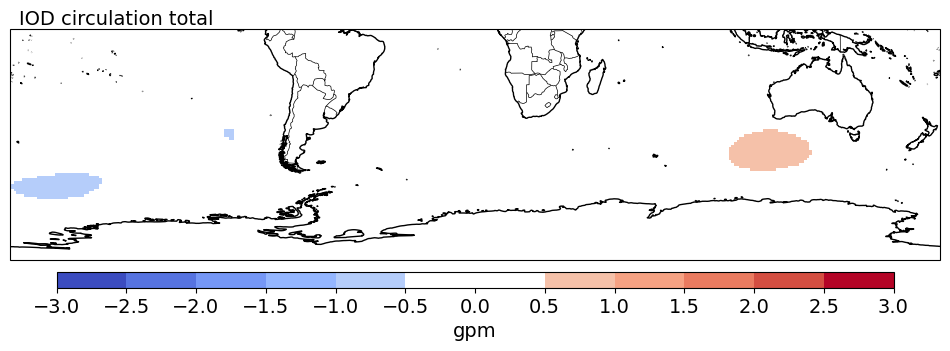

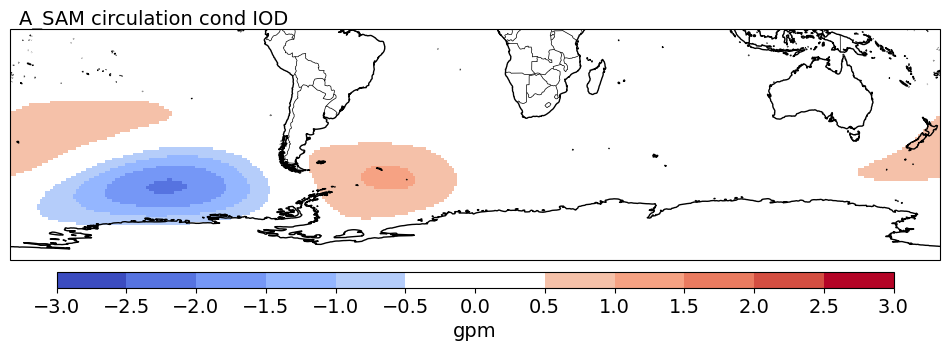

In [18]:
plot_map(1, z500_IOD_A_SAM_SON[0], 'IOD circulation total', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/IOD_Z500_total_copy.jpg')

plot_map(1, z500_IOD_A_SAM_SON[1], 'A_SAM circulation cond IOD', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/A_SAM_IOD_cond_Z500_total_copy.jpg')

In [16]:
z500_all=conditioning_everything_fast(z500_chunked_SON, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'Z500')
z500_all_comp=[m.compute() for m in z500_all]

ENSO done
IOD done
SPV done
S_SAM done
A_SAM done


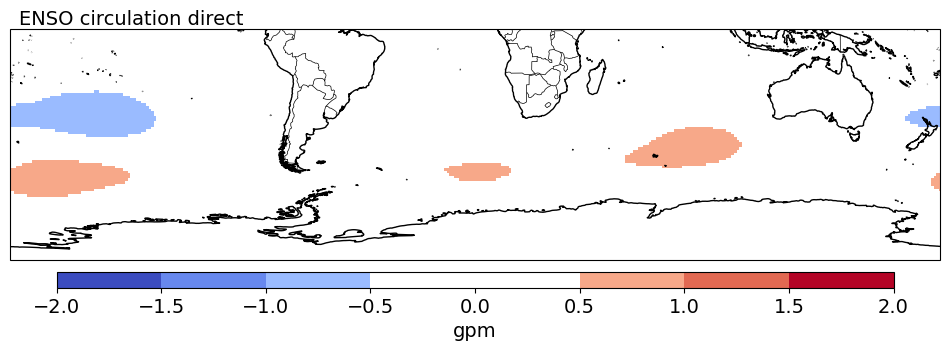

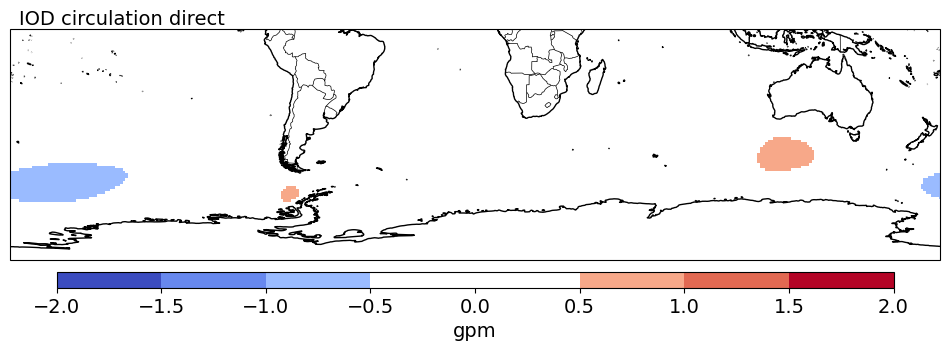

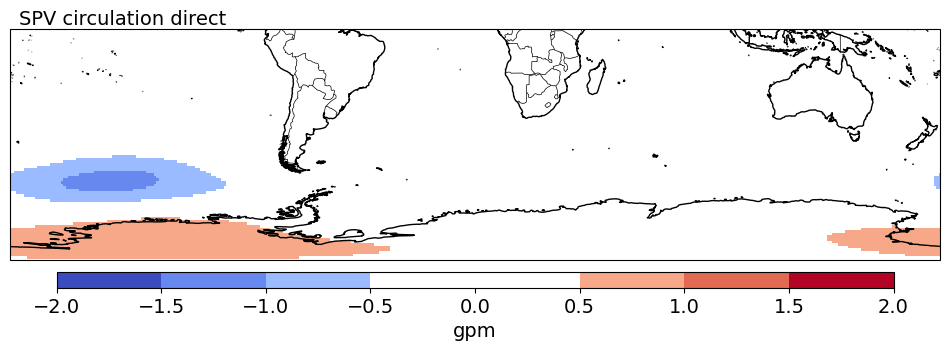

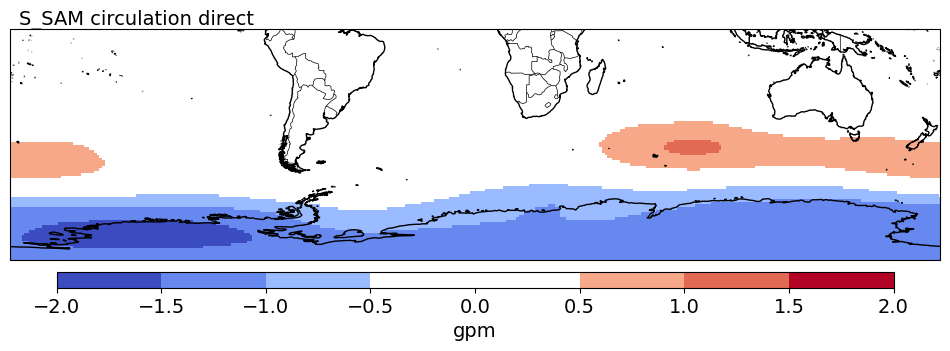

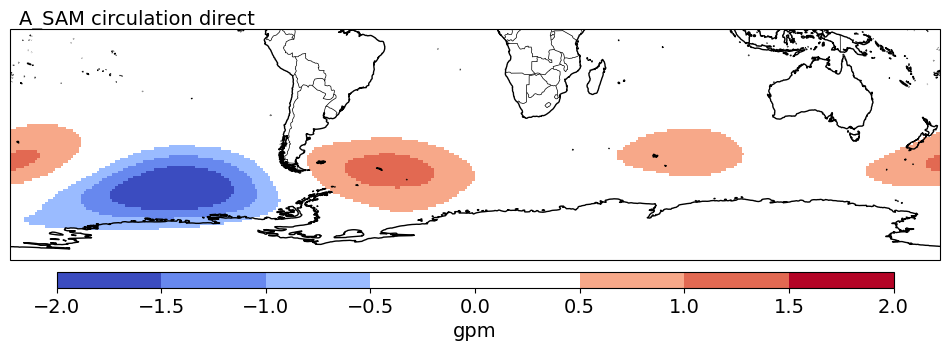

In [27]:
plot_map(1, z500_all_comp[0], 'ENSO circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/ENSO_Z500_direct_SON.jpg')

plot_map(1, z500_all_comp[1], 'IOD circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/IOD_Z500_direct_SON.jpg')

plot_map(1, z500_all_comp[2], 'SPV circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/SPV_Z500_direct_SON.jpg')

plot_map(1, z500_all_comp[3], 'S_SAM circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/S_SAM_Z500_direct_SON.jpg')

plot_map(1, z500_all_comp[len(z500_all_comp)-1], 'A_SAM circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/A_SAM_Z500_direct_SON.jpg')


In [18]:
z500_IOD_SON = conditioning_everything_fast(z500_chunked_SON, ['IOD'],'Z500')
z500_IOD_SON=[m.compute() for m in z500_IOD_SON]

IOD done


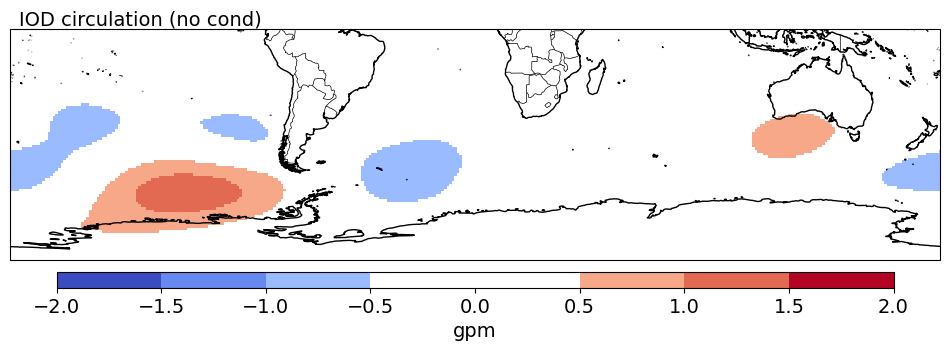

In [28]:
plot_map(1, z500_IOD_SON[0], 'IOD circulation (no cond)', 'gpm', plt.figure(figsize=(12,4)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/IOD_Z500_solo_SON.jpg')


Summer starts here DJF!

In [20]:
z500_all_DJF=conditioning_everything_fast(z500_chunked_DJF, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'Z500')
z500_all_comp_DJF=[m.compute() for m in z500_all_DJF]

ENSO done
IOD done
SPV done
S_SAM done
A_SAM done


In [21]:
z500_all_comp_DJF

[<xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[0.00149237, 0.00150359, 0.00154781, ..., 0.00122796, 0.00129554,
         0.00133405],
        [0.00123388, 0.00150507, 0.00166885, ..., 0.00066337, 0.00085074,
         0.00106153],
        [0.00289666, 0.00319628, 0.00347581, ..., 0.00204259, 0.00234265,
         0.0026539 ],
        ...,
        [0.32309724, 0.32509817, 0.32725341, ..., 0.31800072, 0.31925265,
         0.32108361],
        [0.32453468, 0.32654817, 0.32849888, ..., 0.31955822, 0.32059698,
         0.3223995 ],
        [0.32518498, 0.32725957, 0.32934004, ..., 0.32016032, 0.32141741,
         0.32315163]], shape=(90, 360))
 Coordinates:
   * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
   * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5,
 <xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[-0.17663683, -0.17655834, -0.1764565 , ..., -0.17695475,
         -0.17688373, -0.17671665],
        [

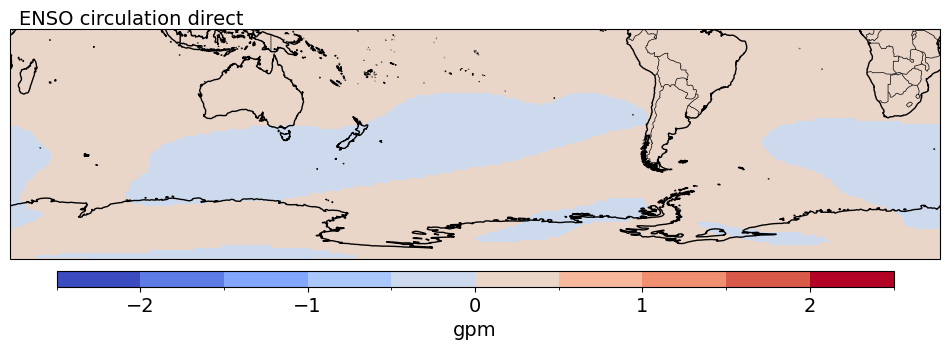

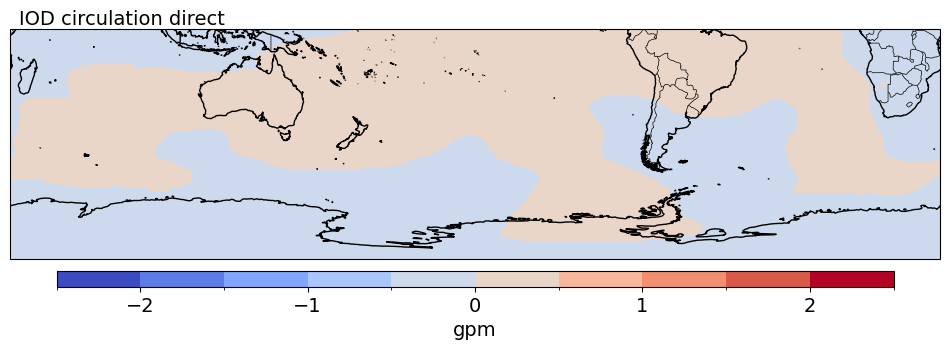

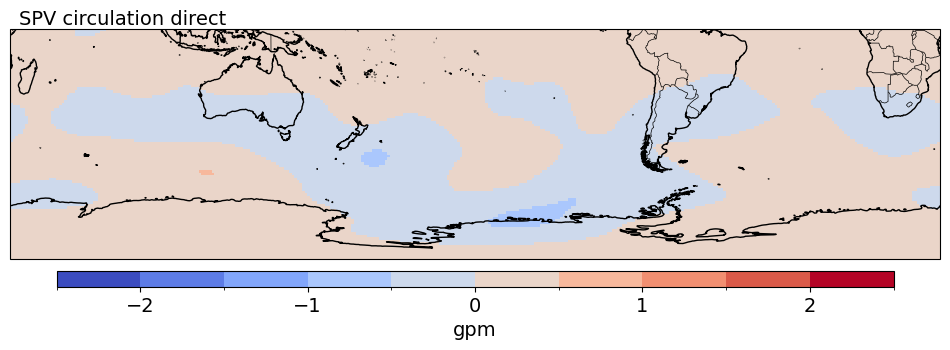

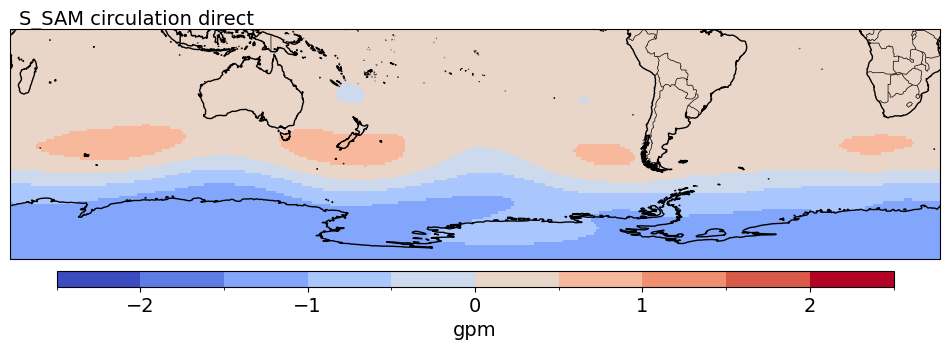

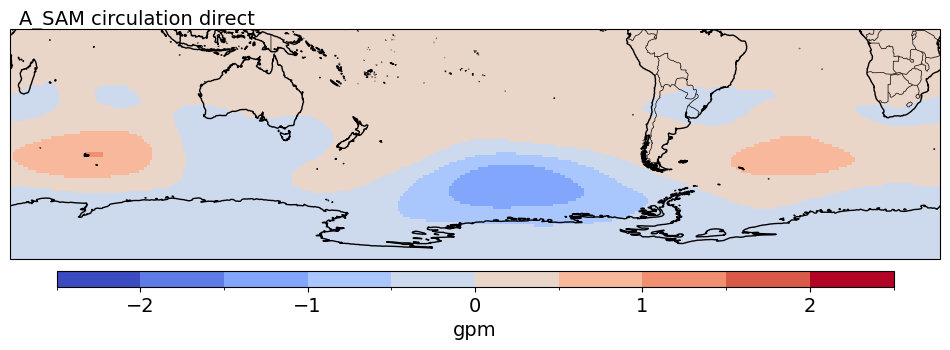

In [22]:
plot_map(1, z500_all_comp_DJF[0], 'ENSO circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/ENSO_Z500_direct_DJF.jpg')

plot_map(1, z500_all_comp_DJF[1], 'IOD circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/IOD_Z500_direct_DJF.jpg')

plot_map(1, z500_all_comp_DJF[2], 'SPV circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/SPV_Z500_direct_DJF.jpg')

plot_map(1, z500_all_comp_DJF[3], 'S_SAM circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/S_SAM_Z500_direct_DJF.jpg')

plot_map(1, z500_all_comp_DJF[len(z500_all_comp_DJF)-1], 'A_SAM circulation direct', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/A_SAM_Z500_direct_DJF.jpg')


In [23]:
z500_IOD_DJF = conditioning_everything_fast(z500_chunked_DJF, ['IOD'],'Z500')
z500_IOD_DJF=[m.compute() for m in z500_IOD_DJF]

IOD done


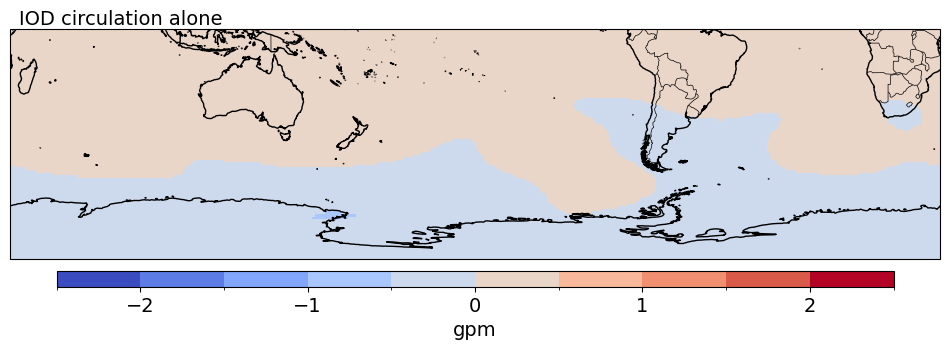

In [24]:
plot_map(1, z500_IOD_DJF[0], 'IOD circulation alone', 'gpm', plt.figure(figsize=(12,4)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/IOD_Z500_solo_DJF.jpg')